# Cell 1 — Environment Setup

Install and import the required libraries for the bone fracture detection project.

This cell also checks GPU availability and displays the available GPU.

In [1]:
# Install YOLO
!pip install -q ultralytics

# Imports
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

# GPU check
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: CPU")

print("PyTorch Version:", torch.__version__)
print("Environment ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 647.2 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 4.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
CUDA Available: True
GPU: Tesla T4
PyTorch Version: 2.10.0+cu128
Environment ready!


# Cell 2 — Load & Verify FracAtlas Dataset

Locate the actual FracAtlas dataset directory and inspect its complete
folder structure, image files, and annotation files.

In [3]:
import os

# Actual dataset root
DATASET_ROOT = "/kaggle/input/datasets/orvile/fracatlas/FracAtlas"

print("Dataset Root:", DATASET_ROOT)
print("\nFolder Structure:\n")

# Show folders and files up to 3 levels deep
for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, "").count(os.sep)

    if level > 3:
        continue

    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

print("\nDataset root verified:", os.path.exists(DATASET_ROOT))

Dataset Root: /kaggle/input/datasets/orvile/fracatlas/FracAtlas

Folder Structure:

FracAtlas/
    dataset.csv
    Utilities/
        yolo2voc.ipynb
        coco2yolo.ipynb
        Fracture Split/
            valid.csv
            train.csv
            test.csv
    Annotations/
        VGG JSON/
            VGG_fracture_masks.json
        PASCAL VOC/
            IMG0001939.xml
            IMG0002524.xml
            IMG0000324.xml
            IMG0001453.xml
            IMG0001782.xml
            IMG0002161.xml
            IMG0002331.xml
            IMG0000541.xml
            IMG0003948.xml
            IMG0000455.xml
        COCO JSON/
            COCO_fracture_masks.json
        YOLO/
            IMG0000924.txt
            IMG0003953.txt
            IMG0001379.txt
            IMG0000986.txt
            IMG0000729.txt
            IMG0002840.txt
            IMG0001324.txt
            IMG0003314.txt
            IMG0003120.txt
            IMG0003735.txt
    images/
        Non_fractured/
  

# Cell 3 — Dataset EDA
Explore class distribution, image dimensions, fracture annotations, and sample X-ray images.

IMAGE STATISTICS
Total readable images : 4083
Unreadable images     : 0
Mean width            : 559.2
Mean height           : 634.4
Min width             : 181
Max width             : 2880
Min height            : 214
Max height            : 2880
Mean aspect ratio     : 0.92

ANNOTATION STATISTICS
Annotation files      : 4084
Total fracture boxes  : 923
Mean boxes/file       : 0.23
Median boxes/file     : 0
Maximum boxes/file    : 5
Files with 1 box      : 547
Files with >1 box     : 171

ANNOTATION COVERAGE
Files with annotations : 718
Files without boxes    : 3366


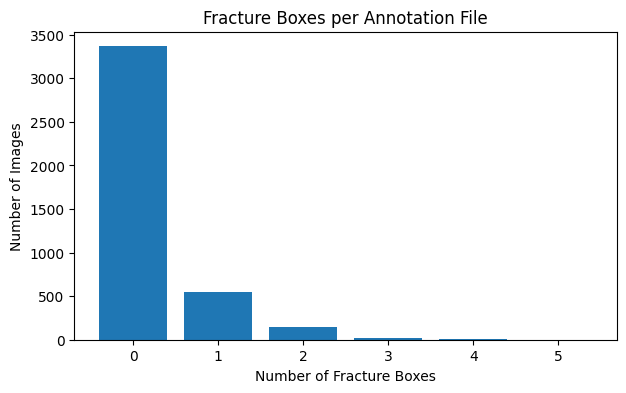

In [9]:
from PIL import Image
from collections import Counter

# Image statistics
dimensions = []
failed_images = 0

for folder, files in [(fractured_dir, fractured_files),
                       (non_fractured_dir, non_fractured_files)]:
    for file in files:
        try:
            with Image.open(os.path.join(folder, file)) as img:
                w, h = img.size
                dimensions.append((w, h))
        except:
            failed_images += 1

widths = [w for w, h in dimensions]
heights = [h for w, h in dimensions]
aspect_ratios = [w / h for w, h in dimensions]

print("IMAGE STATISTICS")
print(f"Total readable images : {len(dimensions)}")
print(f"Unreadable images     : {failed_images}")
print(f"Mean width            : {np.mean(widths):.1f}")
print(f"Mean height           : {np.mean(heights):.1f}")
print(f"Min width             : {min(widths)}")
print(f"Max width             : {max(widths)}")
print(f"Min height            : {min(heights)}")
print(f"Max height            : {max(heights)}")
print(f"Mean aspect ratio     : {np.mean(aspect_ratios):.2f}")

# Annotation statistics
annotation_stats = []

for file in os.listdir(yolo_dir):
    if file.endswith(".txt"):
        with open(os.path.join(yolo_dir, file), "r") as f:
            lines = [x.strip() for x in f if x.strip()]
        annotation_stats.append(len(lines))

box_counter = Counter(annotation_stats)

print("\nANNOTATION STATISTICS")
print(f"Annotation files      : {len(annotation_stats)}")
print(f"Total fracture boxes  : {sum(annotation_stats)}")
print(f"Mean boxes/file       : {np.mean(annotation_stats):.2f}")
print(f"Median boxes/file     : {np.median(annotation_stats):.0f}")
print(f"Maximum boxes/file    : {max(annotation_stats)}")
print(f"Files with 1 box      : {box_counter.get(1, 0)}")
print(f"Files with >1 box     : {sum(v for k, v in box_counter.items() if k > 1)}")

# Annotation coverage
annotated_files = sum(1 for x in annotation_stats if x > 0)

print("\nANNOTATION COVERAGE")
print(f"Files with annotations : {annotated_files}")
print(f"Files without boxes    : {len(annotation_stats) - annotated_files}")

# Box distribution plot
plt.figure(figsize=(7, 4))
plt.bar(box_counter.keys(), box_counter.values())
plt.xlabel("Number of Fracture Boxes")
plt.ylabel("Number of Images")
plt.title("Fracture Boxes per Annotation File")
plt.xticks(sorted(box_counter.keys()))
plt.show()

# Cell 4 — Sample Images with Fracture Annotations
Visualize sample X-rays with their YOLO bounding boxes to verify annotation quality and alignment.

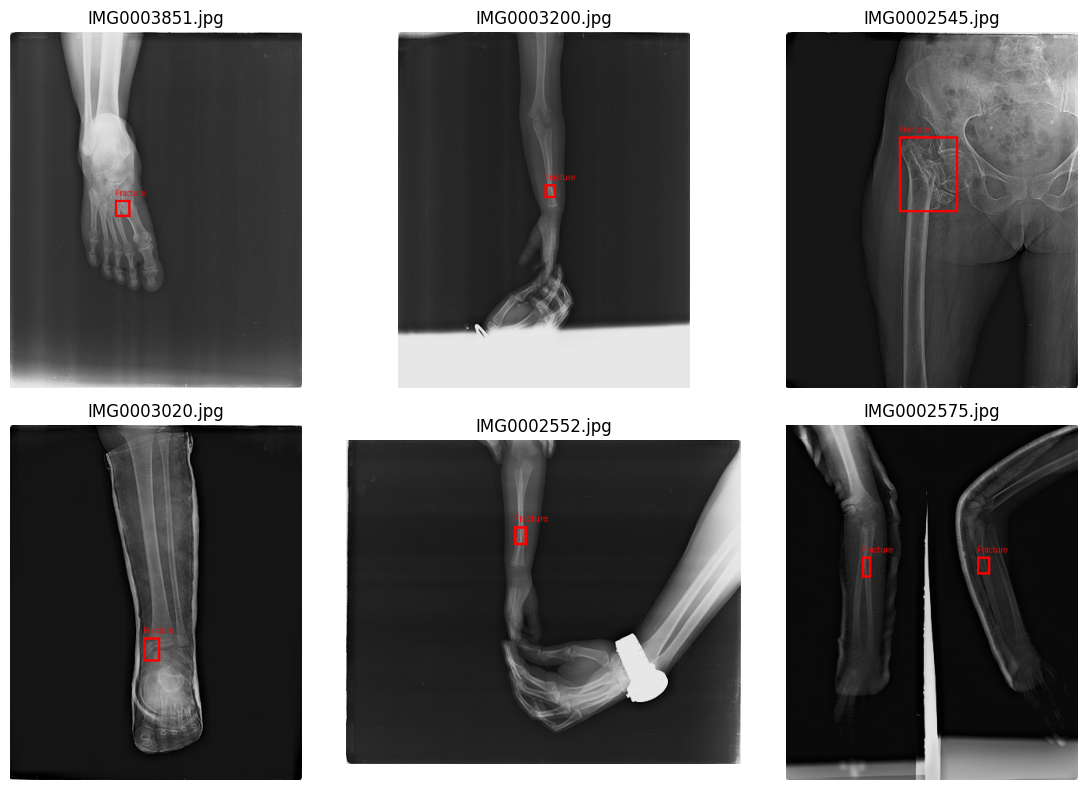

In [10]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Select annotated images
annotation_files = [
    f for f in os.listdir(yolo_dir)
    if f.endswith(".txt") and os.path.getsize(os.path.join(yolo_dir, f)) > 0
]

samples = random.sample(annotation_files, min(6, len(annotation_files)))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, ann_file in zip(axes, samples):
    image_name = os.path.splitext(ann_file)[0] + ".jpg"
    
    # Find image in Fractured folder
    image_path = os.path.join(fractured_dir, image_name)
    
    if not os.path.exists(image_path):
        ax.axis("off")
        continue
    
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        draw = ImageDraw.Draw(img)
        w, h = img.size
        
        with open(os.path.join(yolo_dir, ann_file), "r") as f:
            annotations = [line.strip().split() for line in f if line.strip()]
        
        for ann in annotations:
            _, xc, yc, bw, bh = map(float, ann)
            
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            
            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
            draw.text((x1, max(0, y1 - 15)), "Fracture", fill="red")
        
        ax.imshow(img)
        ax.set_title(image_name)
        ax.axis("off")

plt.tight_layout()
plt.show()

# Cell 5 — Dataset Preparation

Use the official FracAtlas train, validation, and test split and prepare the dataset for YOLOv8 training.

In [11]:
import os
import shutil
import pandas as pd

split_dir = os.path.join(DATASET_ROOT, "Utilities", "Fracture Split")

train_csv = os.path.join(split_dir, "train.csv")
val_csv = os.path.join(split_dir, "valid.csv")
test_csv = os.path.join(split_dir, "test.csv")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Train samples :", len(train_df))
print("Val samples   :", len(val_df))
print("Test samples  :", len(test_df))

print("\nCSV columns:")
print(train_df.columns.tolist())

Train samples : 574
Val samples   : 82
Test samples  : 61

CSV columns:
['image_id']


# Cell 6 — Preprocessing & Augmentation

Prepare the YOLO training pipeline with controlled preprocessing and augmentation.

Augmentation is applied only during training, while validation and test images remain unaugmented.

### Preprocessing Strategy
YOLOv8 will handle image resizing and normalization during training. Controlled augmentation will be applied only to the training set to improve robustness while keeping validation and test evaluation unbiased.

In [42]:
# Preprocessing and augmentation configuration

IMG_SIZE = 600
BATCH_SIZE = 16

AUGMENTATION = {
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "degrees": 0.0,
    "translate": 0.1,
    "scale": 0.5,
    "fliplr": 0.5,
    "flipud": 0.0,
    "mosaic": 1.0
}

print("Image Size       :", IMG_SIZE)
print("Batch Size       :", BATCH_SIZE)
print("Augmentation     : YOLO standard augmentation")
print("Validation/Test  : No augmentation")
print("Preprocessing    : YOLO native resize + normalization")

Image Size       : 600
Batch Size       : 16
Augmentation     : YOLO standard augmentation
Validation/Test  : No augmentation
Preprocessing    : YOLO native resize + normalization


# Cell 7 — YOLOv8s Model Setup & Hyperparameters

Load the pretrained YOLOv8s model and define the training configuration for fracture localization. Training will be performed separately in the next cell.

In [47]:
# YOLOv8s model setup

MODEL_NAME = "yolov8s.pt"
model = YOLO(MODEL_NAME)

IMG_SIZE = 600
BATCH_SIZE = 16

EPOCHS = 30
PATIENCE = 30

LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.0005
OPTIMIZER = "SGD"

print("Model           :", MODEL_NAME)
print("Image Size      :", IMG_SIZE)
print("Batch Size      :", BATCH_SIZE)
print("Epochs          :", EPOCHS)
print("Early Stopping  :", PATIENCE)
print("Learning Rate   :", LEARNING_RATE)
print("Weight Decay    :", WEIGHT_DECAY)
print("Optimizer       :", OPTIMIZER)
print("Model setup ready!")

Model           : yolov8s.pt
Image Size      : 600
Batch Size      : 16
Epochs          : 30
Early Stopping  : 30
Learning Rate   : 0.01
Weight Decay    : 0.0005
Optimizer       : SGD
Model setup ready!


# Cell 8 — YOLO Dataset Preparation

Prepare the official FracAtlas train, validation, and test splits in YOLO format using the existing images and YOLO annotations. The original dataset will not be modified.

In [16]:
# Create YOLO dataset from the official FracAtlas splits

import os
import shutil
import yaml

YOLO_ROOT = "/kaggle/working/fracatlas_yolo"
IMAGE_ROOT = os.path.join(DATASET_ROOT, "images")
LABEL_ROOT = os.path.join(DATASET_ROOT, "Annotations", "YOLO")

# Create YOLO folder structure
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(YOLO_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_ROOT, "labels", split), exist_ok=True)

split_dfs = {
    "train": train_df,
    "val": val_df,
    "test": test_df
}

stats = {}

for split, df in split_dfs.items():
    copied_images = 0
    copied_labels = 0
    missing_images = []
    missing_labels = []

    for image_id in df["image_id"]:
        image_id = str(image_id)

        # Find image in Fractured or Non_fractured folder
        image_path = None

        for folder in ["Fractured", "Non_fractured"]:
            candidate = os.path.join(IMAGE_ROOT, folder, image_id)
            if os.path.exists(candidate):
                image_path = candidate
                break

        if image_path is None:
            missing_images.append(image_id)
            continue

        # Copy image
        destination_image = os.path.join(
            YOLO_ROOT, "images", split, image_id
        )
        shutil.copy2(image_path, destination_image)
        copied_images += 1

        # Find corresponding YOLO annotation
        label_name = os.path.splitext(image_id)[0] + ".txt"
        label_path = os.path.join(LABEL_ROOT, label_name)

        if os.path.exists(label_path):
            destination_label = os.path.join(
                YOLO_ROOT, "labels", split, label_name
            )
            shutil.copy2(label_path, destination_label)
            copied_labels += 1
        else:
            missing_labels.append(image_id)

    stats[split] = {
        "images": copied_images,
        "labels": copied_labels,
        "missing_images": len(missing_images),
        "missing_labels": len(missing_labels)
    }

# Create data.yaml
data_yaml = {
    "path": YOLO_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "fractured"
    }
}

DATA_YAML = os.path.join(YOLO_ROOT, "data.yaml")

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("YOLO dataset created successfully!\n")

for split, result in stats.items():
    print(
        f"{split.upper():5} | "
        f"Images: {result['images']:3} | "
        f"Labels: {result['labels']:3} | "
        f"Missing Images: {result['missing_images']:3} | "
        f"Missing Labels: {result['missing_labels']:3}"
    )

print("\nData YAML:", DATA_YAML)
print("Dataset Path:", YOLO_ROOT)

YOLO dataset created successfully!

TRAIN | Images: 574 | Labels: 574 | Missing Images:   0 | Missing Labels:   0
VAL   | Images:  82 | Labels:  82 | Missing Images:   0 | Missing Labels:   0
TEST  | Images:  61 | Labels:  61 | Missing Images:   0 | Missing Labels:   0

Data YAML: /kaggle/working/fracatlas_yolo/data.yaml
Dataset Path: /kaggle/working/fracatlas_yolo


# Cell 9 — YOLOv8n Model Training

Fine-tune the pretrained YOLOv8n model on the FracAtlas fracture localization dataset using the configured hyperparameters and training augmentations.

In [48]:
# Train YOLOv8s on FracAtlas

RUN_NAME = "yolov8s_fracture_final_baseline"

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    optimizer=OPTIMIZER,
    lr0=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    hsv_h=AUGMENTATION["hsv_h"],
    hsv_s=AUGMENTATION["hsv_s"],
    hsv_v=AUGMENTATION["hsv_v"],
    degrees=AUGMENTATION["degrees"],
    translate=AUGMENTATION["translate"],
    scale=AUGMENTATION["scale"],
    fliplr=AUGMENTATION["fliplr"],
    flipud=AUGMENTATION["flipud"],
    mosaic=AUGMENTATION["mosaic"],
    close_mosaic=10,
    pretrained=True,
    project="/kaggle/working/fracatlas_training",
    name=RUN_NAME,
    exist_ok=False,
    verbose=True
)

print("Training completed!")
print("Run:", RUN_NAME)

Ultralytics 8.4.158 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fracatlas_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=600, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_fracture_final_baseline-3, n

# Cell 10 — Final Validation

Evaluate the trained YOLOv8s model on the official validation set.

This cell calculates:
- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95

The test set is not used at this stage.

In [49]:
# Final validation of the trained model

FINAL_BEST = "/kaggle/working/fracatlas_training/yolov8s_fracture_final_baseline/weights/best.pt"

final_model = YOLO(FINAL_BEST)

val_results = final_model.val(
    data=DATA_YAML,
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    plots=True,
    verbose=True
)

print("\nFinal Validation Results")
print("Precision    :", round(val_results.box.mp, 4))
print("Recall       :", round(val_results.box.mr, 4))
print("mAP@50       :", round(val_results.box.map50, 4))
print("mAP@50-95    :", round(val_results.box.map, 4))

WARNING ⚠️ imgsz=[600] must be multiple of max stride 32, updating to [608]
Ultralytics 8.4.158 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 638.5±198.4 MB/s, size: 19.9 KB)
val: Scanning /kaggle/working/fracatlas_yolo/labels/val.cache... 82 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 20.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.2it/s 1.9s0.3s
                   all         82         91      0.587      0.538      0.553      0.247
Speed: 3.2ms preprocess, 9.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

Final Validation Results
Precision    : 0.587
Recall       : 0.5385
mAP@50       : 0.5534
mAP@50-95    : 0.2474


# Cell 11 — Validation Plots and Export

Display all generated validation plots and save them in a ZIP folder.

All exported plots are saved at 8 × 6 inches and 300 DPI for report or documentation use.

Plots found: 6
Saved: BoxF1_curve.png


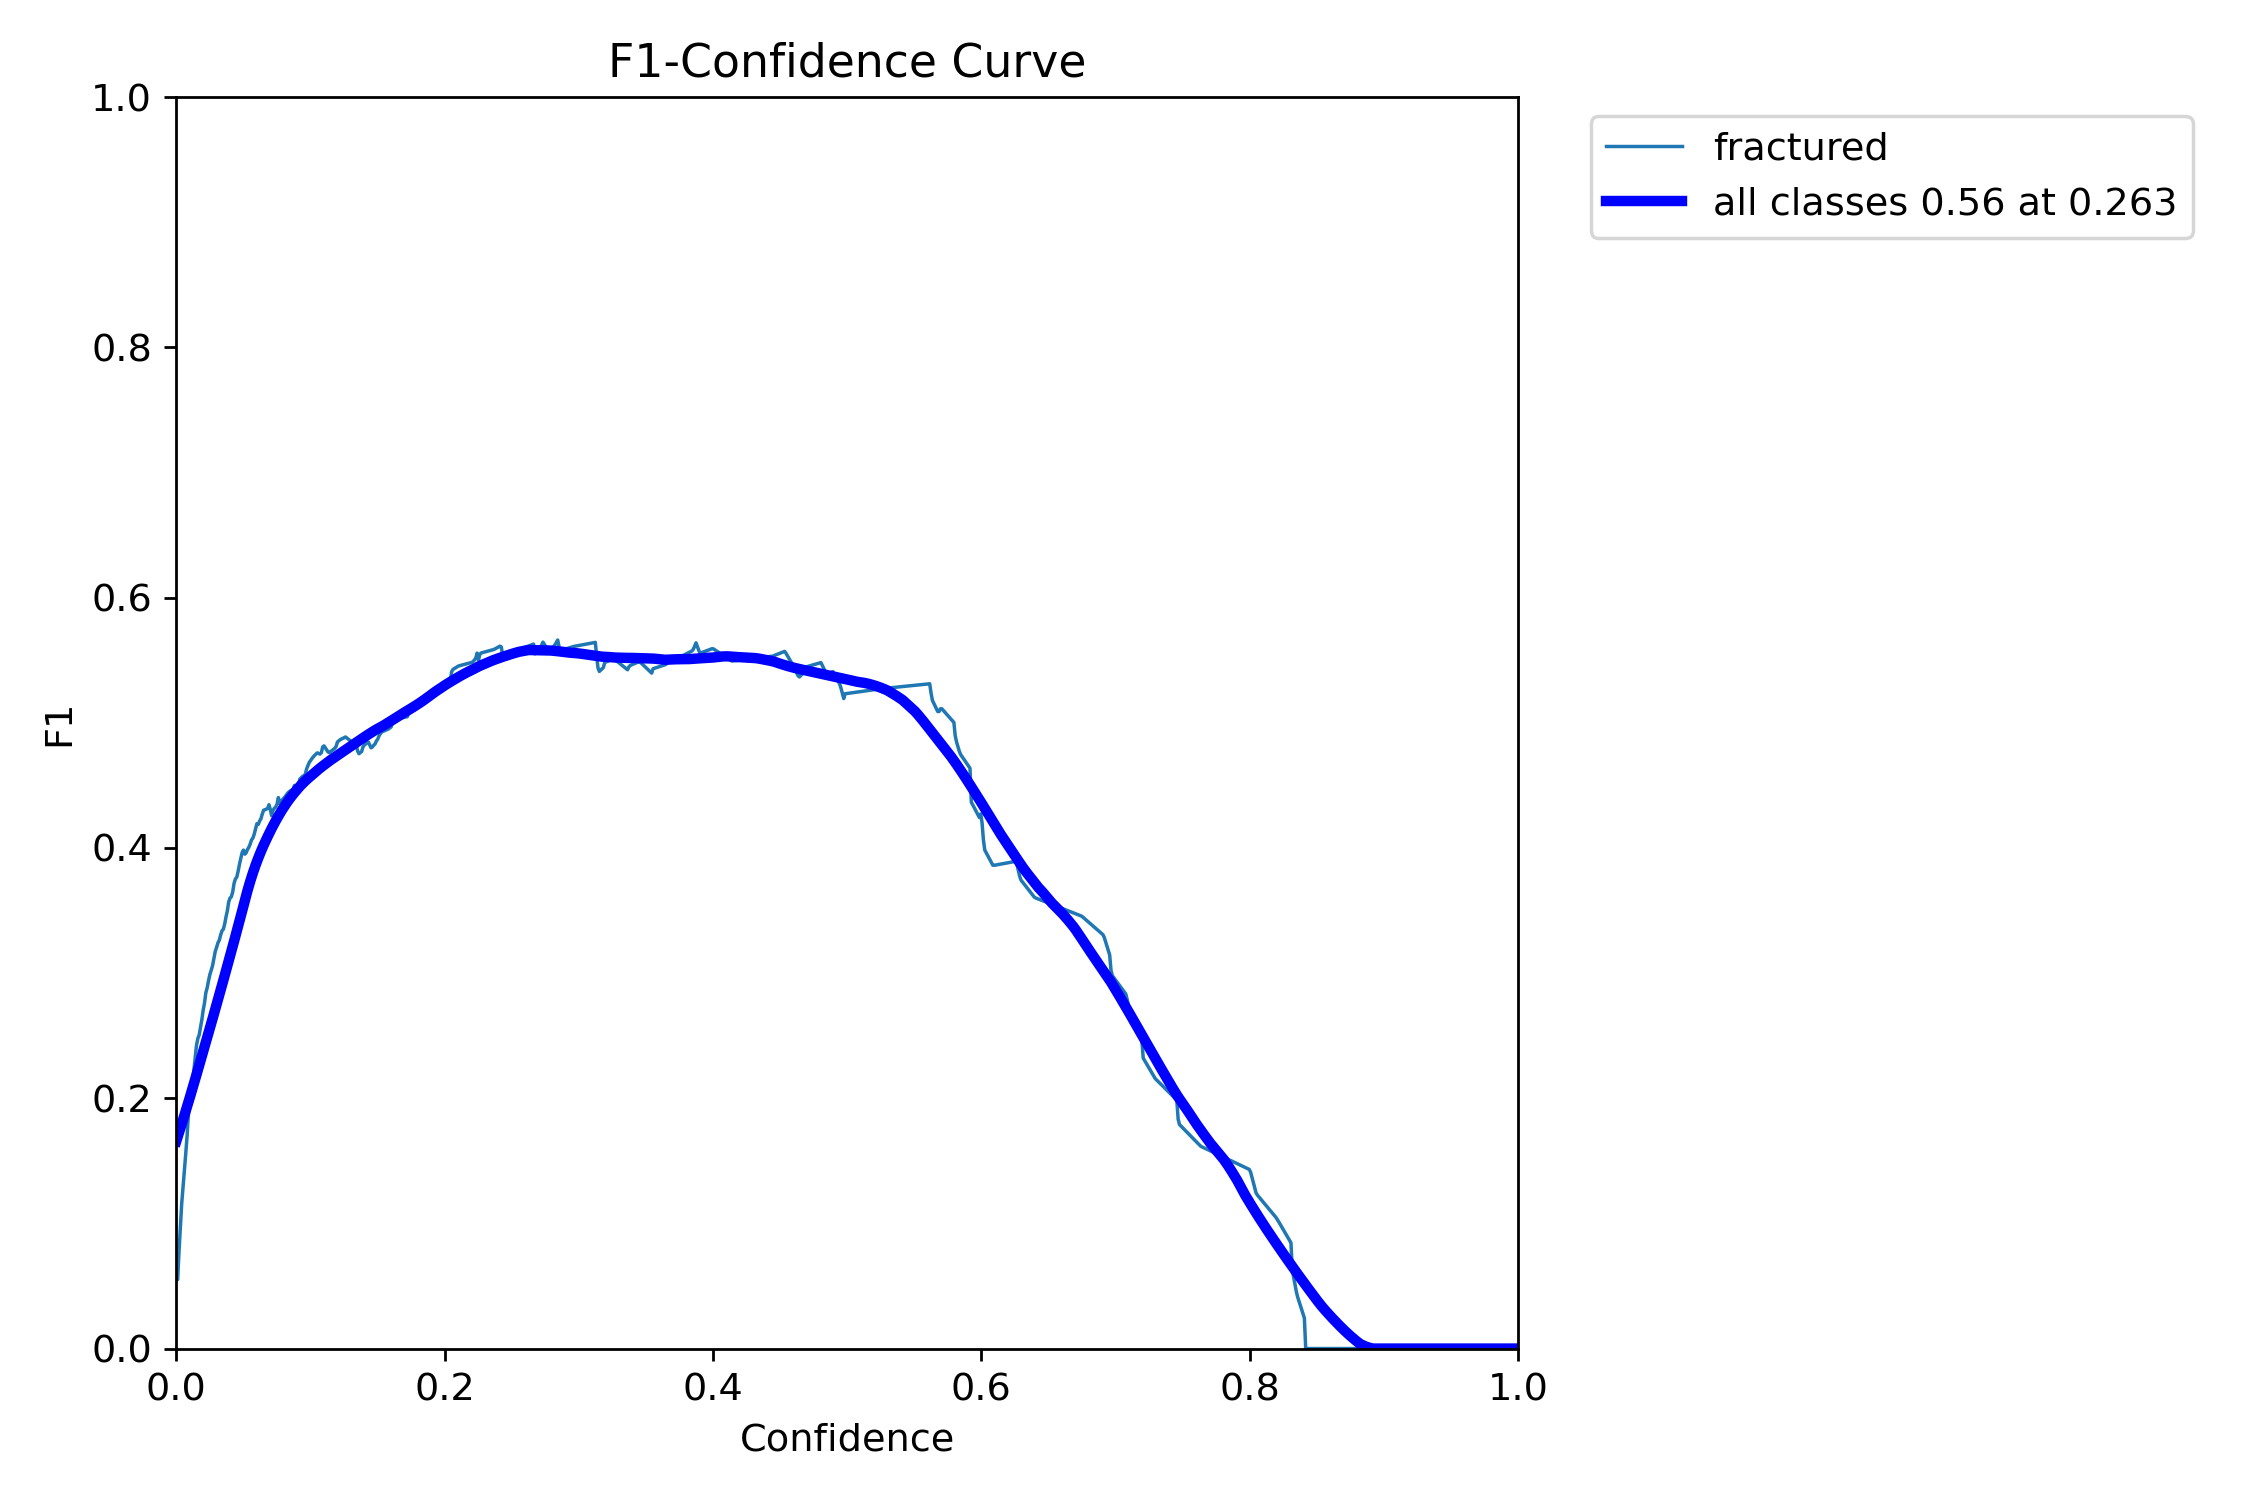

Saved: BoxPR_curve.png


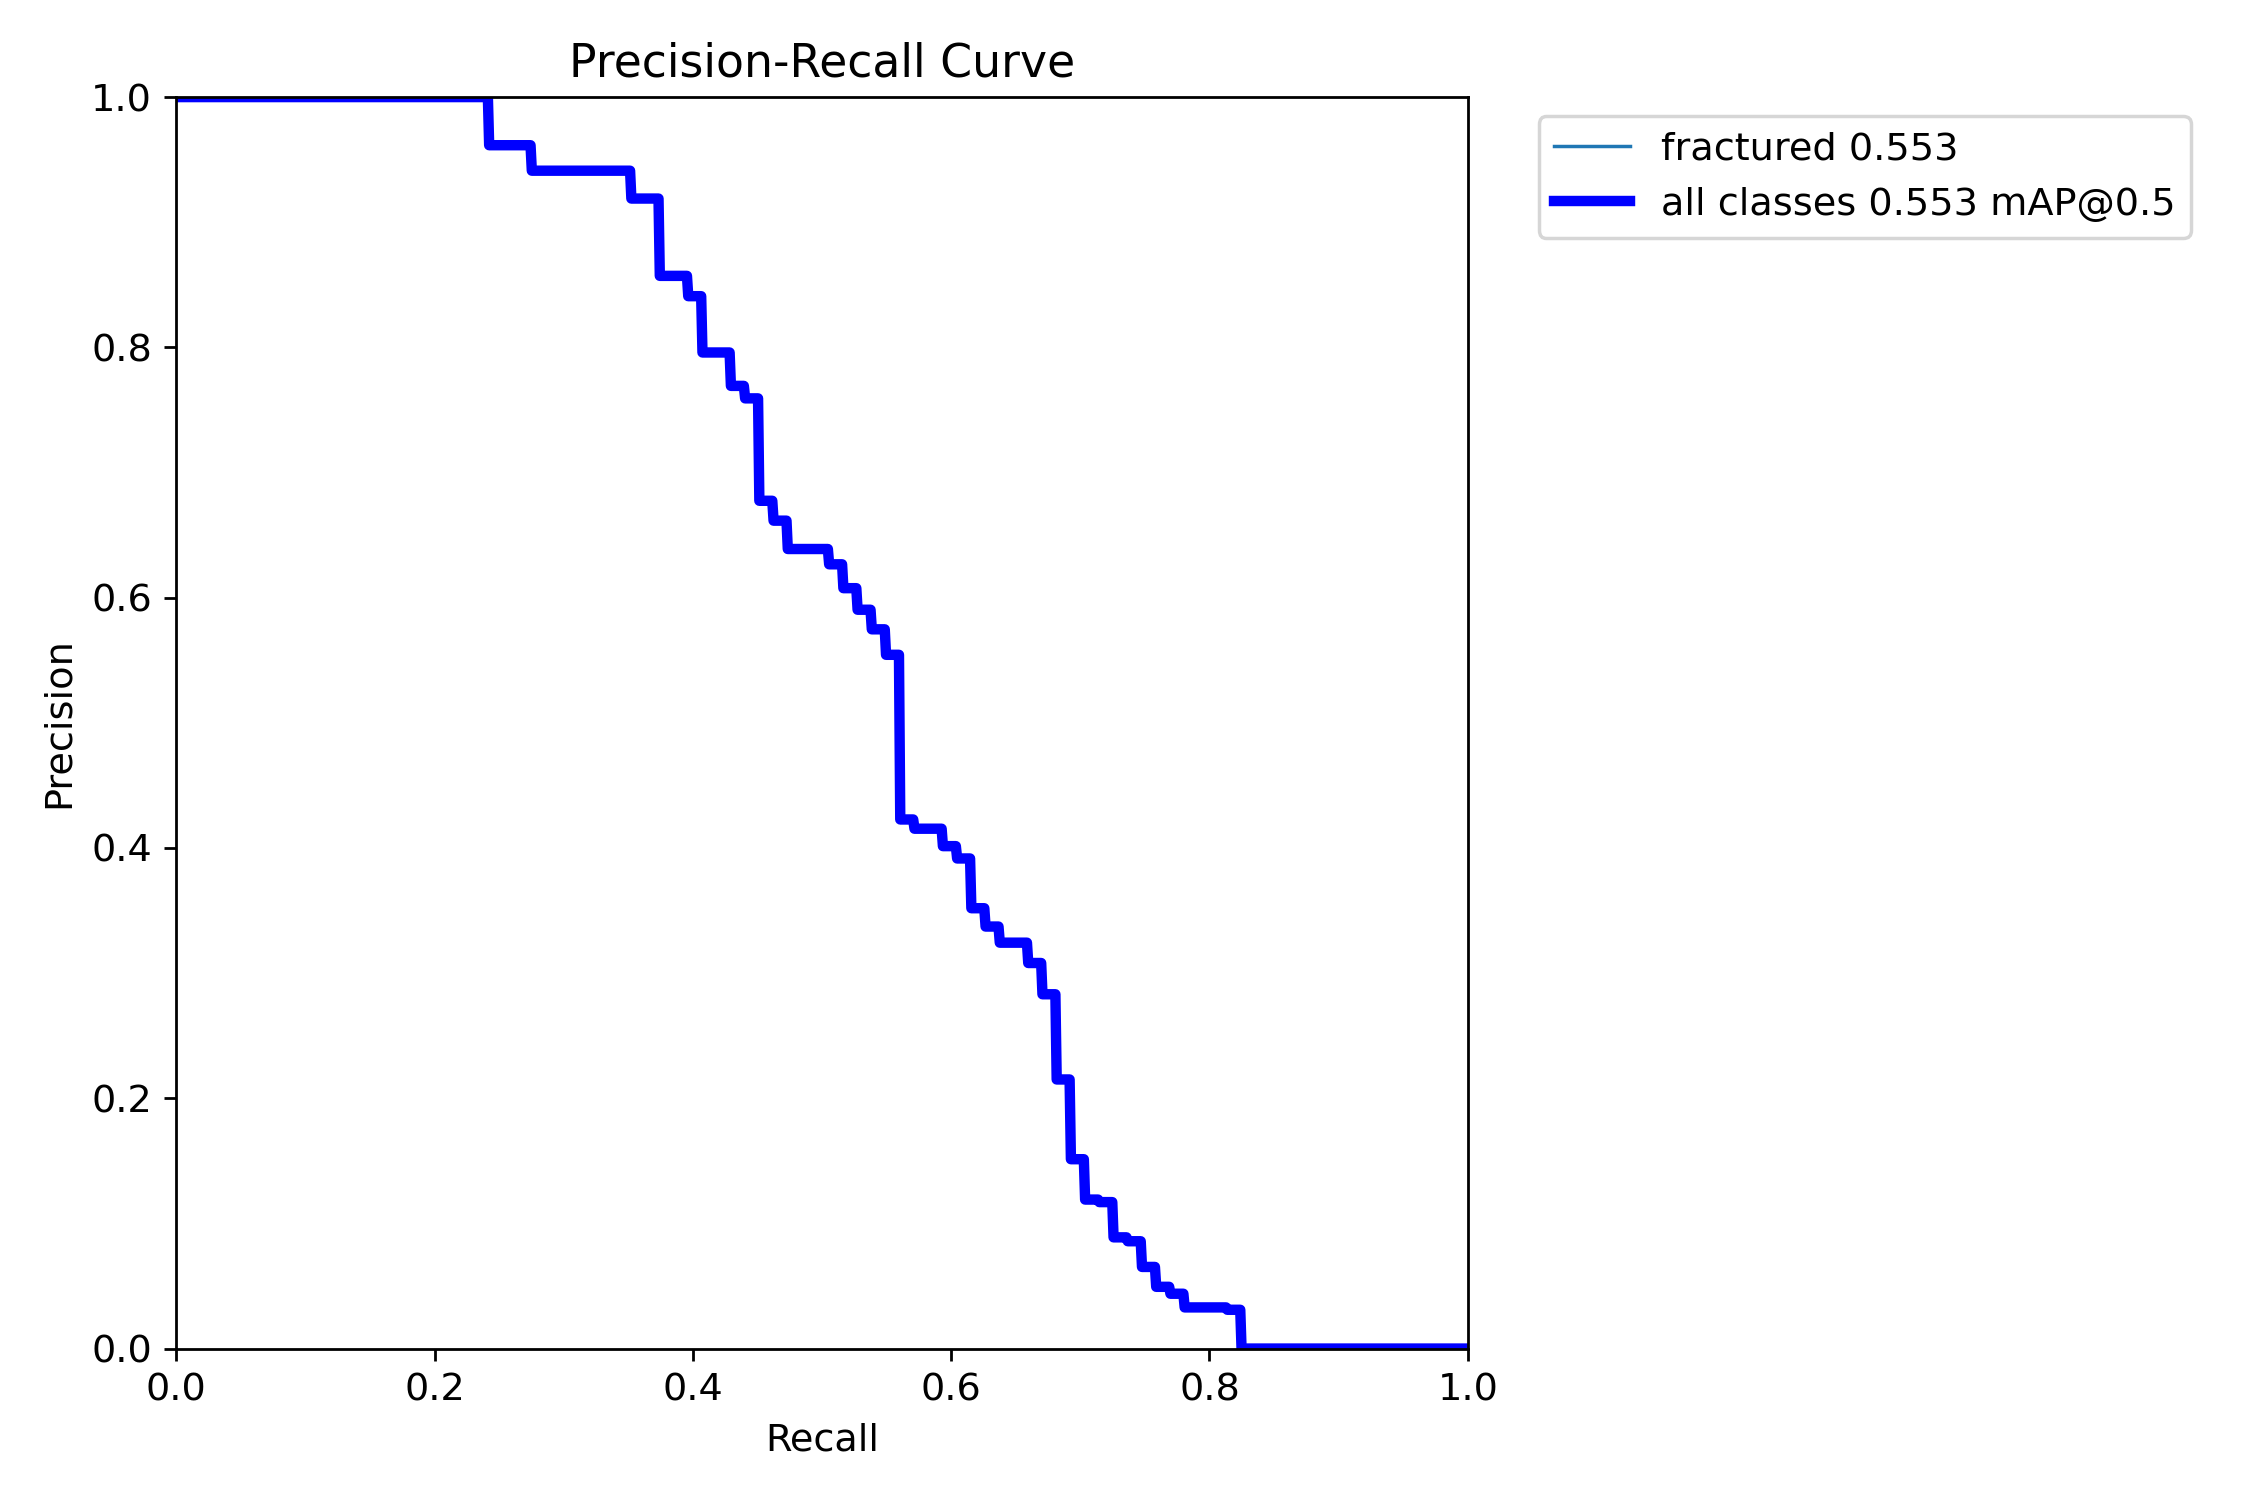

Saved: BoxP_curve.png


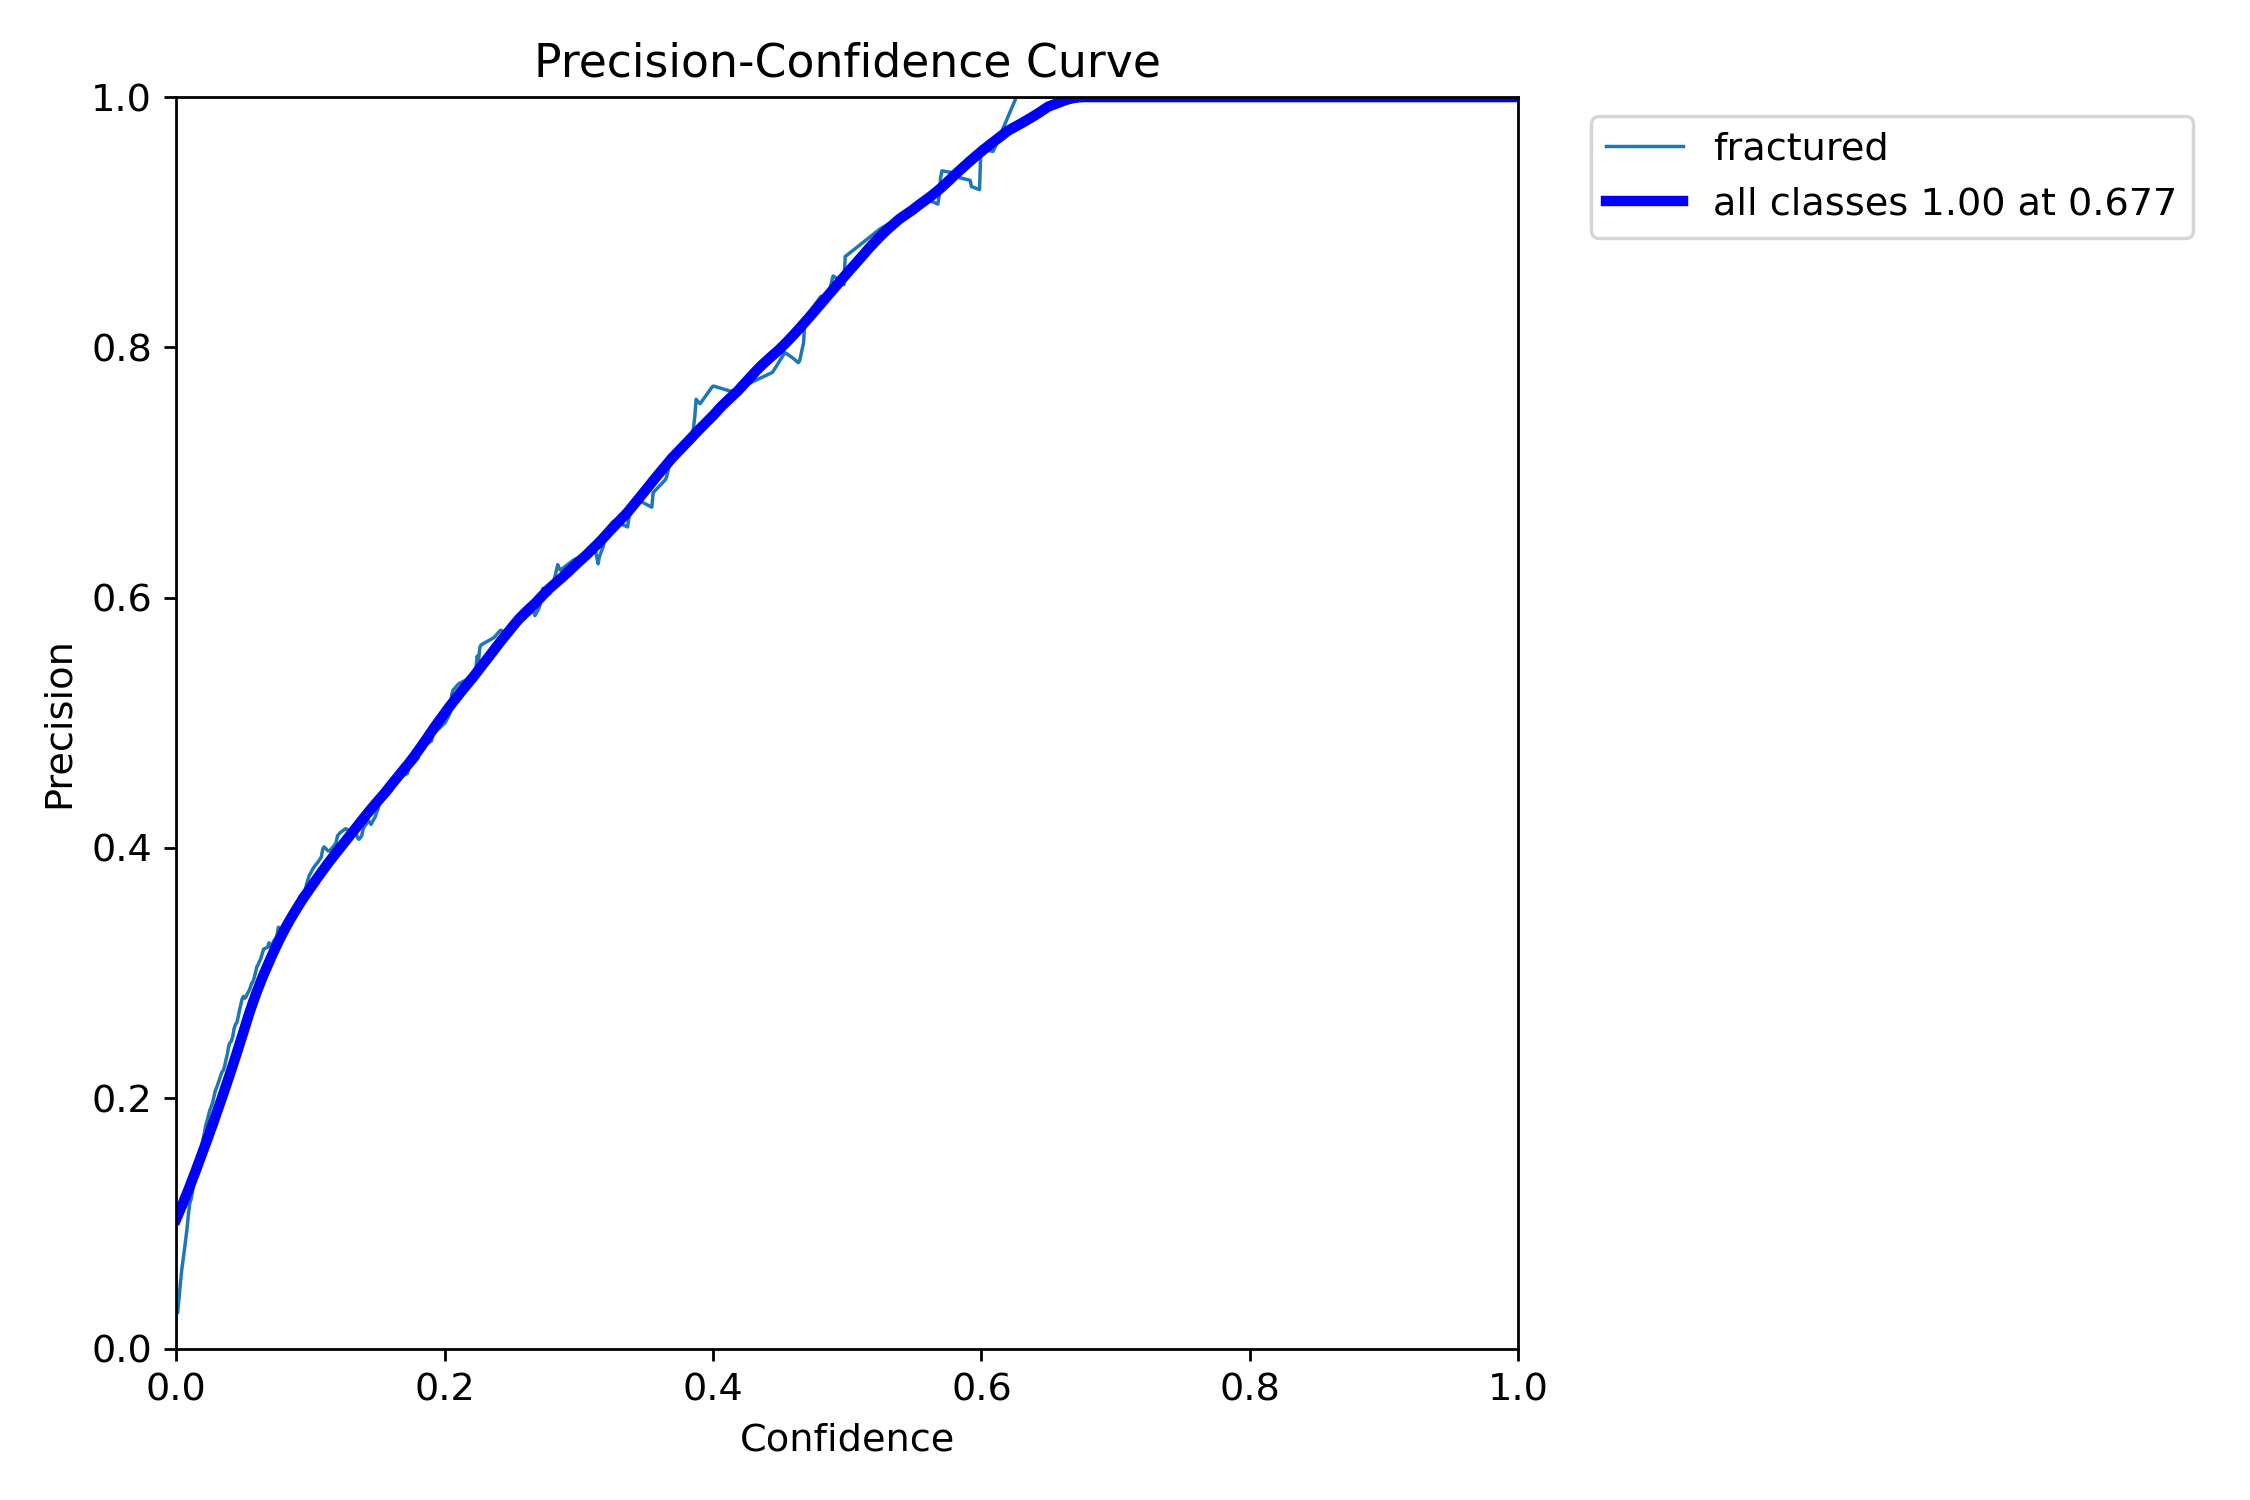

Saved: BoxR_curve.png


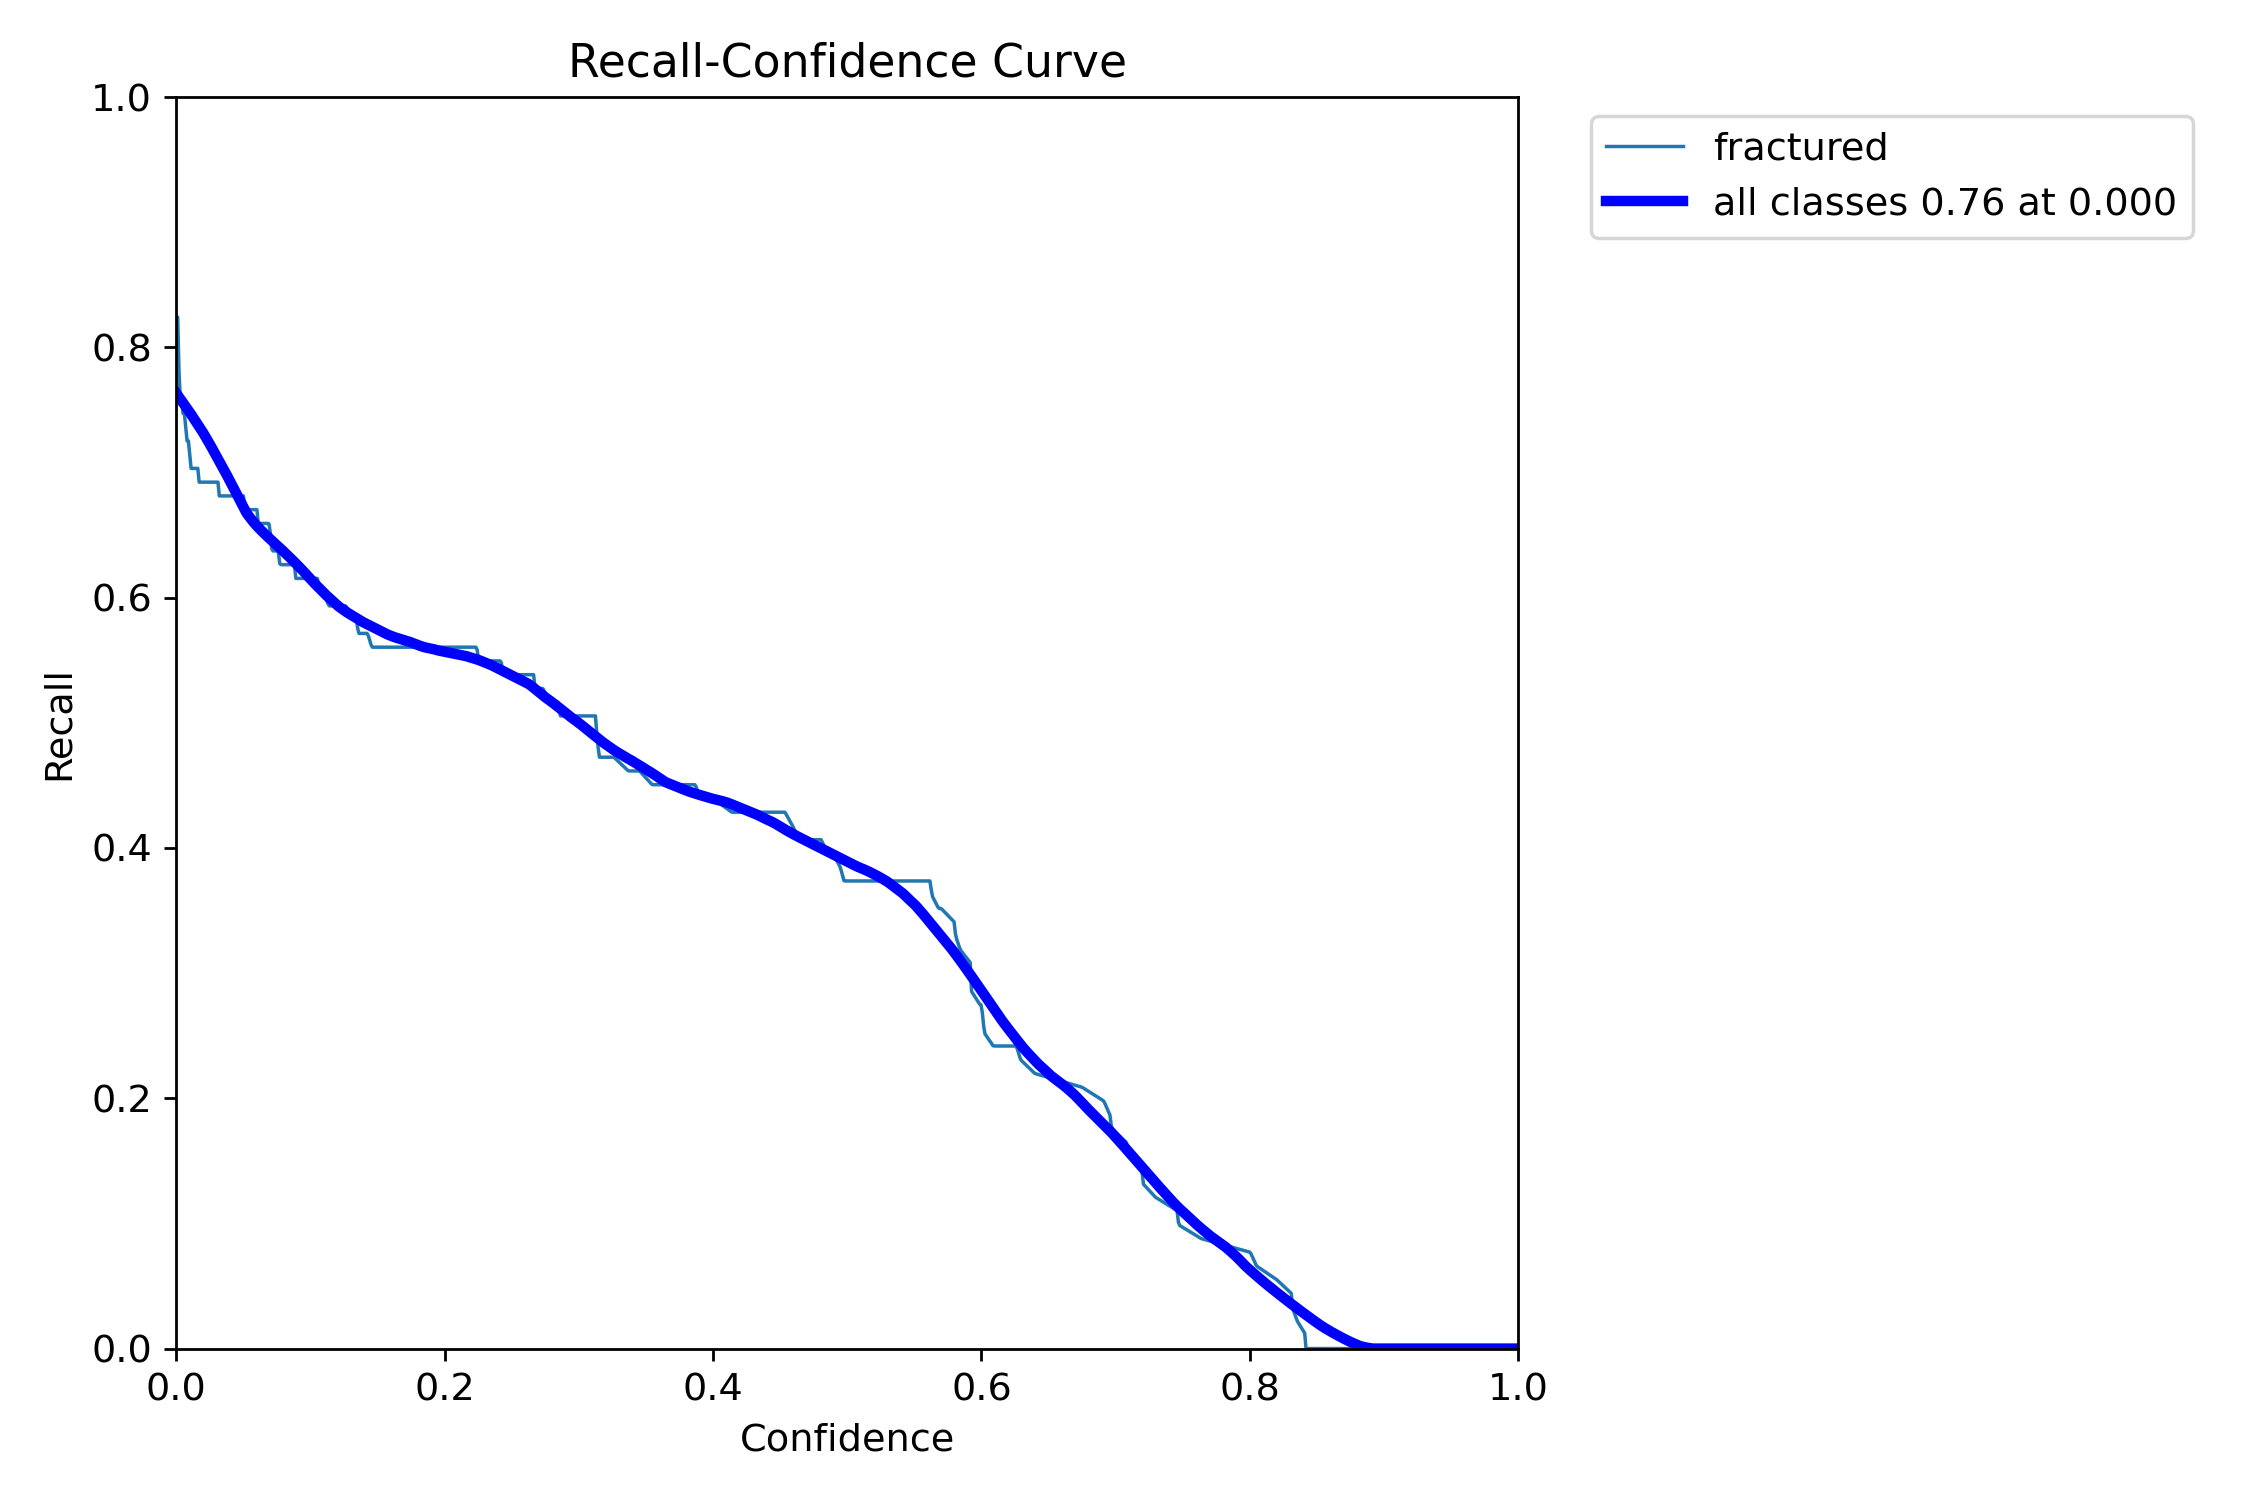

Saved: confusion_matrix.png


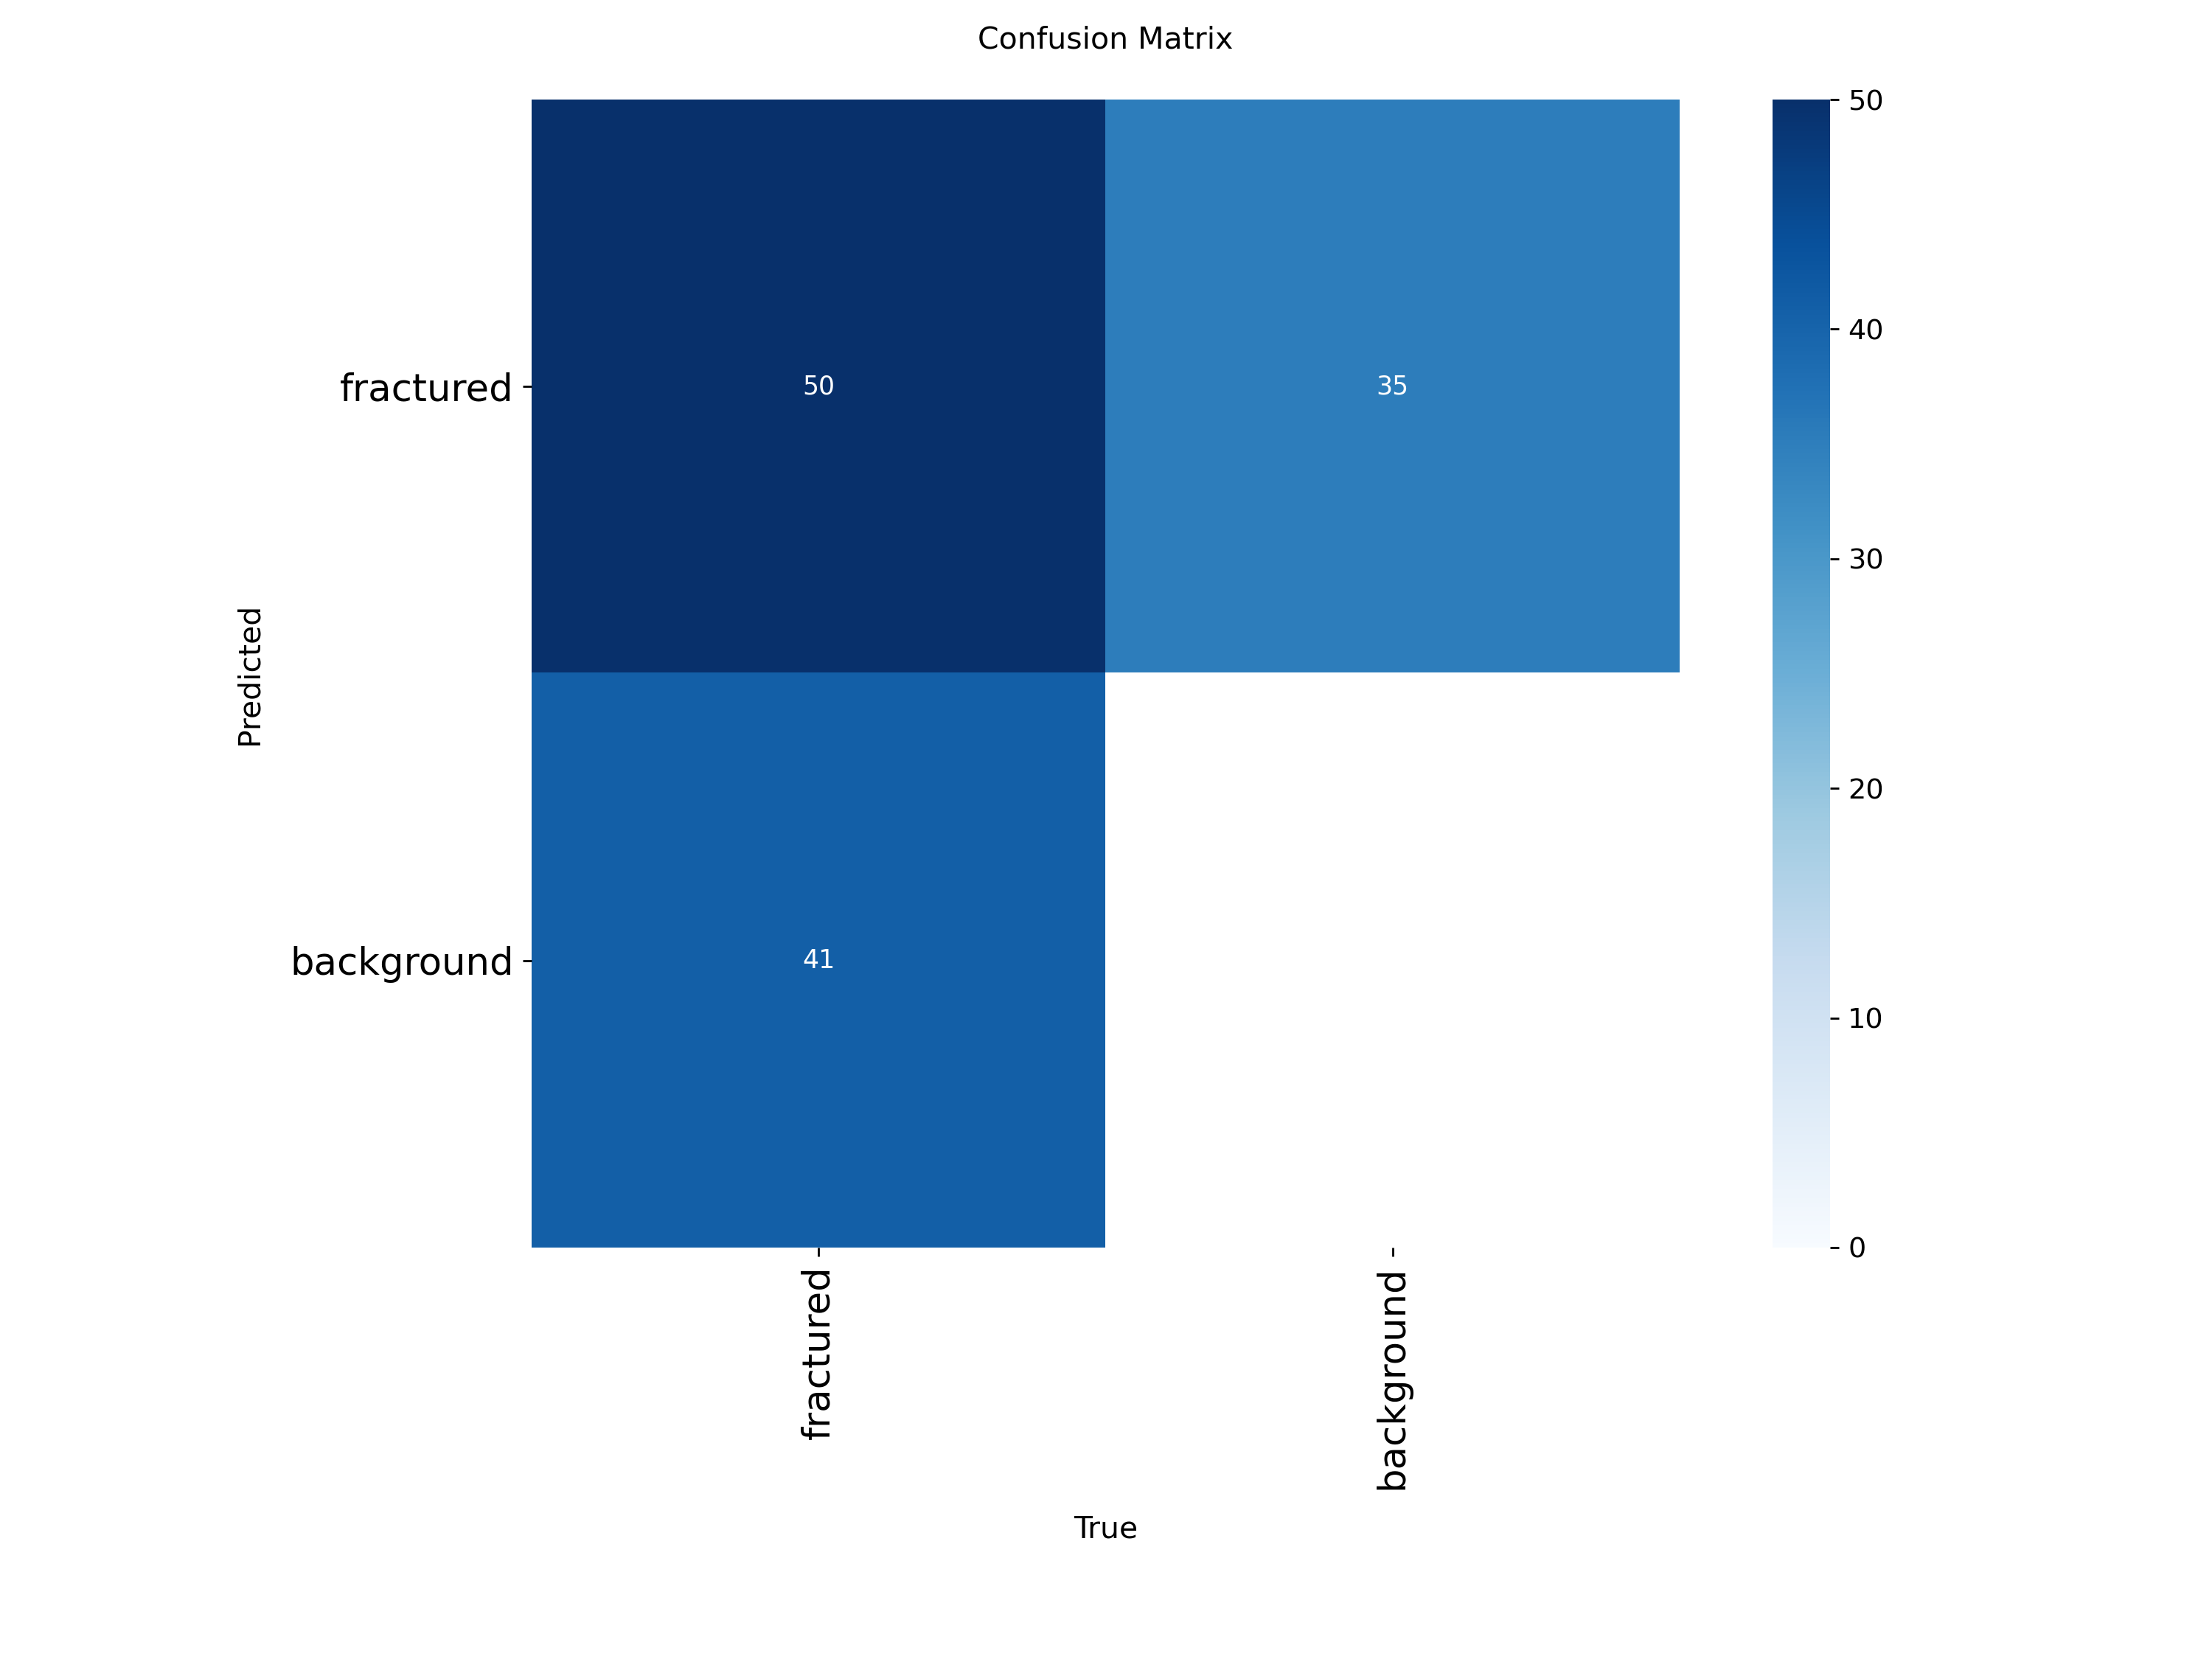

Saved: confusion_matrix_normalized.png


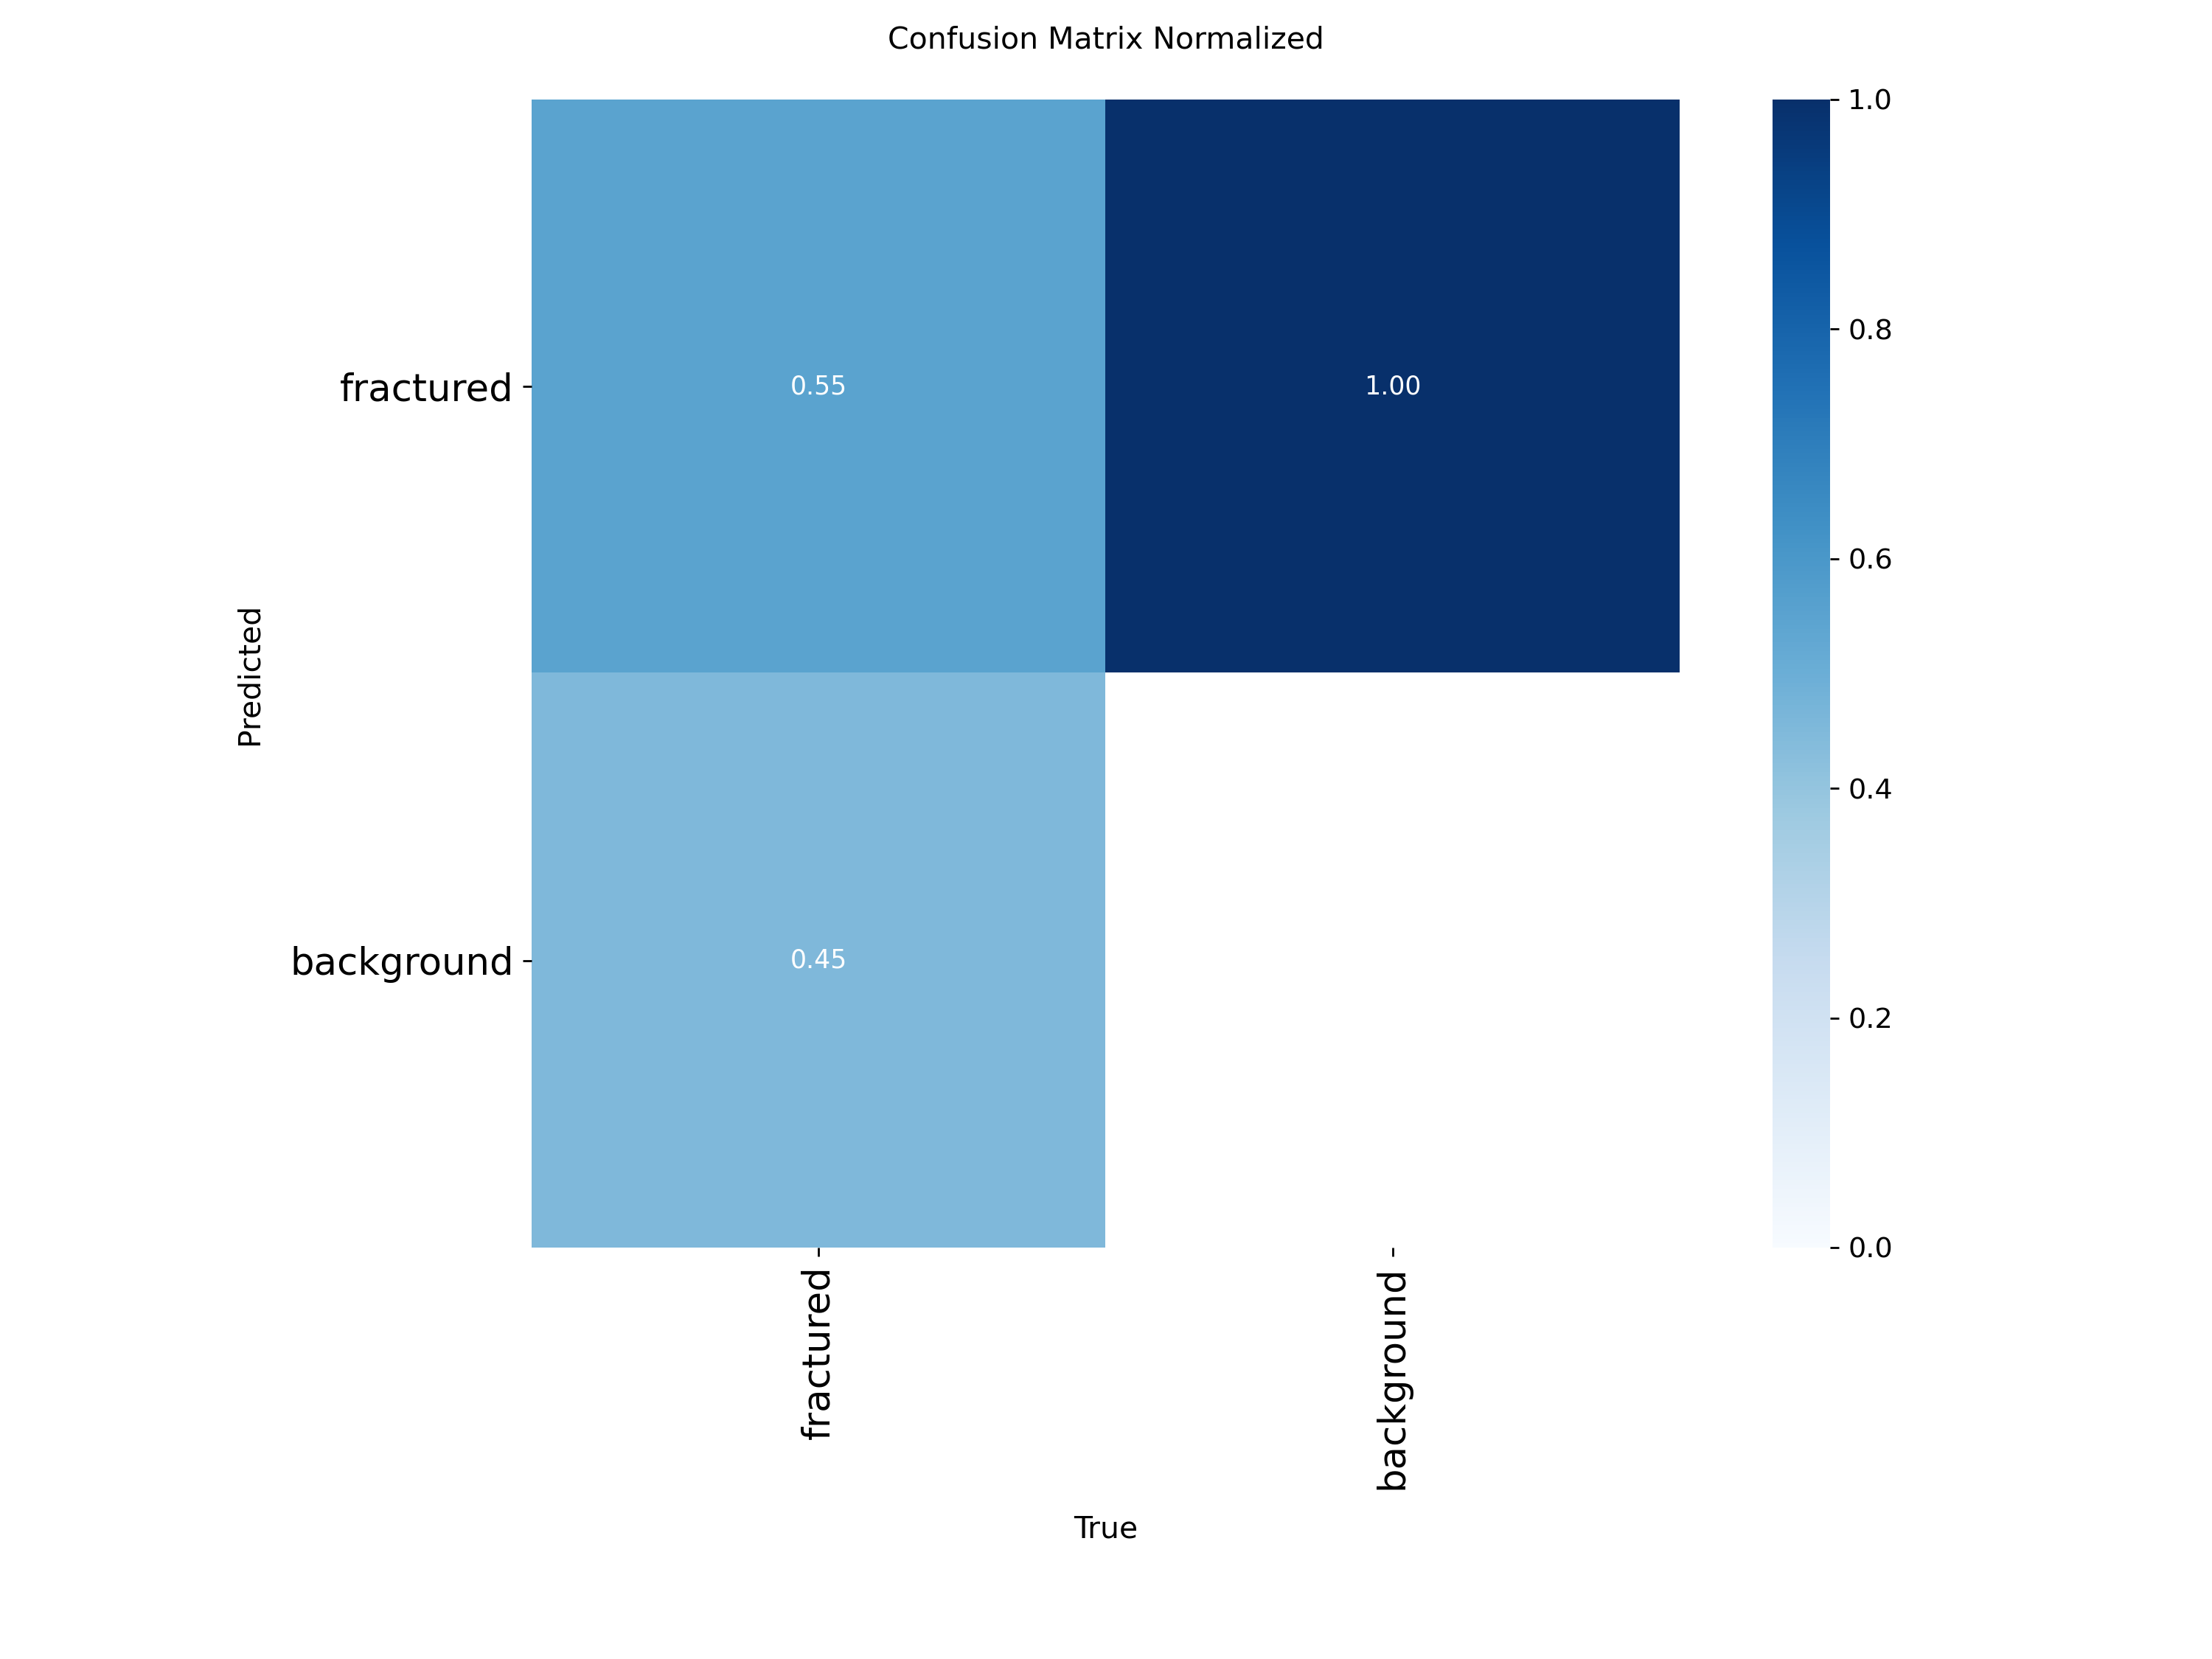


ZIP created successfully!
ZIP: /kaggle/working/validation_plots_8x6_300dpi.zip


In [52]:
# Display and export validation plots

import os
import shutil
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import display, Image

VAL_DIR = str(val_results.save_dir)
EXPORT_DIR = "/kaggle/working/validation_plots_8x6_300dpi"
ZIP_PATH = "/kaggle/working/validation_plots_8x6_300dpi.zip"

os.makedirs(EXPORT_DIR, exist_ok=True)

plot_files = []

for root, dirs, files in os.walk(VAL_DIR):
    for file in files:
        if file.endswith(".png"):
            plot_files.append(os.path.join(root, file))

print("Plots found:", len(plot_files))

for file_path in sorted(plot_files):
    filename = os.path.basename(file_path)
    output_path = os.path.join(EXPORT_DIR, filename)

    img = PILImage.open(file_path).convert("RGB")

    width, height = img.size
    fig = plt.figure(figsize=(8, 6), dpi=300)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout(pad=0)

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close(fig)

    print("Saved:", filename)
    display(Image(filename=file_path))

# Create ZIP file
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(
    "/kaggle/working/validation_plots_8x6_300dpi",
    "zip",
    EXPORT_DIR
)

print("\nZIP created successfully!")
print("ZIP:", ZIP_PATH)

In [53]:
# Save final best YOLOv8s model

import os
import shutil

SOURCE_BEST = str(results.save_dir / "weights" / "best.pt")
FINAL_MODEL_DIR = "/kaggle/working/final_model"
FINAL_BEST = os.path.join(FINAL_MODEL_DIR, "best.pt")

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

shutil.copy2(SOURCE_BEST, FINAL_BEST)

print("Final model saved successfully!")
print("Best Model :", FINAL_BEST)
print("File Size  :", round(os.path.getsize(FINAL_BEST) / (1024 * 1024), 2), "MB")

Final model saved successfully!
Best Model : /kaggle/working/final_model/best.pt
File Size  : 21.46 MB
